In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.stats import ks_2samp
import warnings 
import gc
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',50)
sns.set_style("whitegrid")

print("All libraries imported")

All libraries imported


In [17]:
#Load & Merge Data

train_transaction=pd.read_csv('../data/train_transaction.csv')
train_identity=pd.read_csv('../data/train_identity.csv')

df= pd.merge(train_transaction,train_identity,on='TransactionID',how='left')
del train_transaction,train_identity
gc.collect()

print(f"Shape before optimization{df.shape}")
print(f"Memory before optimization:{df.memory_usage().sum()/1024**2:.1f}MB")
#Memory Optimization

def reduce_memory(df):
    for col in df.columns:
        col_type=df[col].dtype
        if col_type=='float64':
            df[col]=df[col].astype('float32')
        elif col_type=='int64':
            if df[col].min()>=0 and df[col].max()<=255:
                df[col]=df[col].astype('uint8')
            elif df[col].min()>=-128 and df[col].max()<=127:
                df[col]=df[col].astype('int8')
            elif df[col].min()>=-32768 and df[col].max()<=32767:
                df[col]=df[col].astype('int16')
            else:
                df[col]=df[col].astype('int32')
    return df
df=reduce_memory(df)
gc.collect()

print(f"Shape after optimization{df.shape}")
print(f"Memory after optimization:{df.memory_usage().sum()/1024**2:.1f}MB")

Shape before optimization(590540, 434)
Memory before optimization:1955.4MB
Shape after optimization(590540, 434)
Memory after optimization:1044.7MB


In [18]:
# ─────────────────────────────────────────
# DROP COLUMNS WITH >90% MISSING VALUES
# ─────────────────────────────────────────

missing_pct = (df.isnull().sum() / len(df)) * 100
cols_to_drop = missing_pct[missing_pct > 90].index.tolist()

print(f" Dropping {len(cols_to_drop)} columns with >90% missing values:")
print(f"   Examples: {cols_to_drop[:10]}...")

df.drop(columns=cols_to_drop, inplace=True)
gc.collect()

print(f"\n Shape after dropping: {df.shape}")
print(f"   Columns remaining: {df.shape[1]}")

 Dropping 12 columns with >90% missing values:
   Examples: ['dist2', 'D7', 'id_07', 'id_08', 'id_18', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25']...

 Shape after dropping: (590540, 422)
   Columns remaining: 422


In [19]:
# ─────────────────────────────────────────
# STANDARD FEATURE ENGINEERING
# ─────────────────────────────────────────

print("=" * 60)
print("ENGINEERING TIME-BASED FEATURES")
print("=" * 60)

# Time features from TransactionDT (seconds from reference)
df['hour']     = ((df['TransactionDT'] // 3600) % 24).astype('int8')
df['day']      = ((df['TransactionDT'] // (3600 * 24)) % 7).astype('int8')

#  Night flag — from YOUR Phase 1 finding!
df['is_night'] = (df['hour'].isin([0, 1, 2, 3, 4, 5])).astype('int8')

#  Peak fraud hours (you found fraud peaks at night)
df['is_fraud_peak_hour'] = (df['hour'].isin([3, 4, 5])).astype('int8')

#  Weekend flag
df['is_weekend'] = (df['day'].isin([5, 6])).astype('int8')

print(f" Time features created:")
print(f"   hour, day, is_night, is_fraud_peak_hour, is_weekend")

# Verify night fraud rate
night_fraud = df[df['is_night'] == 1]['isFraud'].mean() * 100
day_fraud   = df[df['is_night'] == 0]['isFraud'].mean() * 100
print(f"\n🌙 Night fraud rate: {night_fraud:.2f}%")
print(f"☀️  Day fraud rate:   {day_fraud:.2f}%")
print(f"📊 Night is {night_fraud/day_fraud:.1f}x more risky!")

ENGINEERING TIME-BASED FEATURES
 Time features created:
   hour, day, is_night, is_fraud_peak_hour, is_weekend

🌙 Night fraud rate: 3.83%
☀️  Day fraud rate:   3.39%
📊 Night is 1.1x more risky!


In [20]:
print("=" * 60)
print("ENGINEERING AMOUNT-BASED FEATURES")
print("=" * 60)

# Log transform (handles skewness)
df['log_amount'] = np.log1p(df['TransactionAmt']).astype('float32')

# Amount cents — fraud often has round numbers
df['amount_cents'] = (
    (df['TransactionAmt'] - df['TransactionAmt'].astype(int))
    .round(2)
    .astype('float32')
)

# Is round amount? (e.g., $100.00, $500.00)
df['is_round_amount'] = (df['amount_cents'] == 0).astype('int8')

# Amount buckets
df['amount_bucket'] = pd.cut(
    df['TransactionAmt'],
    bins=[0, 50, 100, 200, 500, 1000, 5000, float('inf')],
    labels=[0, 1, 2, 3, 4, 5, 6]
).astype('float32')

print(f"✅ Amount features created:")
print(f"   log_amount, amount_cents, is_round_amount, amount_bucket")

# Check: do round amounts correlate with fraud?
round_fraud = df[df['is_round_amount'] == 1]['isFraud'].mean() * 100
non_round   = df[df['is_round_amount'] == 0]['isFraud'].mean() * 100
print(f"\n💰 Round amount fraud rate:     {round_fraud:.2f}%")
print(f"💰 Non-round amount fraud rate: {non_round:.2f}%")

ENGINEERING AMOUNT-BASED FEATURES
✅ Amount features created:
   log_amount, amount_cents, is_round_amount, amount_bucket

💰 Round amount fraud rate:     3.58%
💰 Non-round amount fraud rate: 3.41%


In [21]:
print("=" * 60)
print("ENGINEERING VELOCITY FEATURES")
print("=" * 60)

# Sort by time for velocity calculations
df = df.sort_values('TransactionDT').reset_index(drop=True)

# ─── Card-level aggregations ───
for col in ['card1', 'card2', 'addr1']:
    if col not in df.columns:
        continue

    # Transaction count per entity
    count_col = f'{col}_txn_count'
    df[count_col] = (df.groupby(col)[col].transform('size')
                     .fillna(0).astype('int32'))

    # Mean transaction amount per entity
    mean_col = f'{col}_mean_amt'
    df[mean_col] = (df.groupby(col)['TransactionAmt'].transform('mean')
                    .fillna(0).astype('float32'))

    # Amount deviation from entity's average
    dev_col = f'{col}_amt_deviation'
    df[dev_col] = (
        (df['TransactionAmt'] - df[mean_col]).abs()
        .fillna(0).astype('float32')
    )

    # Std of amount per entity
    std_col = f'{col}_std_amt'
    df[std_col] = (df.groupby(col)['TransactionAmt'].transform('std')
                   .fillna(0).astype('float32'))

    print(f"✅ {col}: {count_col}, {mean_col}, {dev_col}, {std_col}")

# ─── Email domain fraud rate encoding ───
for email_col in ['P_emaildomain', 'R_emaildomain']:
    if email_col not in df.columns:
        continue
    fraud_rate_map = df.groupby(email_col)['isFraud'].mean()
    df[f'{email_col}_fraud_rate'] = (
        df[email_col].map(fraud_rate_map).fillna(0).astype('float32')
    )
    print(f"✅ {email_col}: fraud rate encoding")

print(f"\n📊 Total features now: {df.shape[1]}")

ENGINEERING VELOCITY FEATURES
✅ card1: card1_txn_count, card1_mean_amt, card1_amt_deviation, card1_std_amt
✅ card2: card2_txn_count, card2_mean_amt, card2_amt_deviation, card2_std_amt
✅ addr1: addr1_txn_count, addr1_mean_amt, addr1_amt_deviation, addr1_std_amt
✅ P_emaildomain: fraud rate encoding
✅ R_emaildomain: fraud rate encoding

📊 Total features now: 445


In [22]:
print("=" * 60)
print("🆕 GRAPH-BASED FEATURE ENGINEERING (UNIQUE)")
print("=" * 60)
print("Building transaction relationship graph...")
print("This may take 2-3 minutes on your laptop — be patient!\n")

# ─────────────────────────────────────────
# Build a graph: cards connected by shared addresses
# Fraud rings share addresses, emails, devices
# ─────────────────────────────────────────

G = nx.Graph()

# Sample for speed (full graph would be too slow on 590K rows)
# Use cards that appear multiple times (more interesting)
card_counts = df['card1'].value_counts()
active_cards = card_counts[card_counts >= 3].index  # Cards with 3+ txns
df_graph = df[df['card1'].isin(active_cards)][['card1', 'addr1']].dropna()

print(f"📊 Building graph from {len(df_graph):,} rows...")
print(f"   Active cards (3+ txns): {len(active_cards):,}")

# Connect cards that share the same billing address
addr_groups = df_graph.groupby('addr1')['card1'].apply(set)

edges_added = 0
for addr, cards in addr_groups.items():
    cards = list(cards)
    if len(cards) < 2 or len(cards) > 50:  # Skip huge groups (noise)
        continue
    for i in range(len(cards)):
        for j in range(i + 1, min(len(cards), i + 10)):  # Cap connections
            G.add_edge(cards[i], cards[j])
            edges_added += 1

print(f"✅ Graph built: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

# ─── Extract graph features ───
print("\nCalculating graph metrics...")

# Degree: how many other cards is this card connected to?
card_degree = dict(G.degree())

# Clustering coefficient: how tightly connected are its neighbors?
card_clustering = nx.clustering(G)

# PageRank: how "important" is this card in the network?
card_pagerank = nx.pagerank(G, max_iter=50, tol=1e-4)

# Map features back to dataframe
df['graph_degree']     = df['card1'].map(card_degree).fillna(0).astype('float32')
df['graph_clustering'] = df['card1'].map(card_clustering).fillna(0).astype('float32')
df['graph_pagerank']   = df['card1'].map(card_pagerank).fillna(0).astype('float32')

# Normalize degree (some cards have 100+ connections)
df['graph_degree_log'] = np.log1p(df['graph_degree']).astype('float32')

# Clean up
del G, df_graph, addr_groups, card_degree, card_clustering, card_pagerank
gc.collect()

print(f"\n✅ Graph features created:")
print(f"   graph_degree, graph_clustering, graph_pagerank, graph_degree_log")

# ─── Validate: do graph features correlate with fraud? ───
print("\n📊 Graph Features vs Fraud:")
for col in ['graph_degree', 'graph_clustering', 'graph_pagerank']:
    fraud_mean     = df[df['isFraud'] == 1][col].mean()
    non_fraud_mean = df[df['isFraud'] == 0][col].mean()
    print(f"   {col}:")
    print(f"     Fraud avg    = {fraud_mean:.6f}")
    print(f"     Non-fraud avg = {non_fraud_mean:.6f}")
    print(f"     Ratio = {fraud_mean / (non_fraud_mean + 1e-9):.2f}x")

🆕 GRAPH-BASED FEATURE ENGINEERING (UNIQUE)
Building transaction relationship graph...
This may take 2-3 minutes on your laptop — be patient!

📊 Building graph from 519,231 rows...
   Active cards (3+ txns): 8,419
✅ Graph built: 445 nodes, 3,719 edges

Calculating graph metrics...

✅ Graph features created:
   graph_degree, graph_clustering, graph_pagerank, graph_degree_log

📊 Graph Features vs Fraud:
   graph_degree:
     Fraud avg    = 26.867445
     Non-fraud avg = 14.105865
     Ratio = 1.90x
   graph_clustering:
     Fraud avg    = 0.310699
     Non-fraud avg = 0.244005
     Ratio = 1.27x
   graph_pagerank:
     Fraud avg    = 0.002752
     Non-fraud avg = 0.001930
     Ratio = 1.43x


In [23]:
print("=" * 60)
print("HANDLING REMAINING MISSING VALUES ")
print("=" * 60)

numerical_cols   = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# ─────────────────────────────────────────
# STEP 1: Create "was_missing" flags BEFORE filling
# The missingness itself can be a fraud signal!
# ─────────────────────────────────────────
missing_flag_count = 0

for col in numerical_cols:
    missing_pct = df[col].isnull().mean() * 100
    # Only create flags for columns with 1-90% missing
    # (>90% already dropped, <1% = not useful)
    if 1 < missing_pct < 90:
        df[f'{col}_was_missing'] = df[col].isnull().astype('int8')
        missing_flag_count += 1

# ─────────────────────────────────────────
# STEP 2: Now fill the actual values
# ─────────────────────────────────────────

# Numerical → fill with median
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Categorical → fill with 'Unknown' (also a signal!)
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna('Unknown')

# Verify
remaining_nulls = df.isnull().sum().sum()
print(f"\n✅ Remaining null values: {remaining_nulls}")

# ─────────────────────────────────────────
# STEP 3: Check if missing flags correlate with fraud
# ─────────────────────────────────────────
missing_flag_cols = [c for c in df.columns if c.endswith('_was_missing')]

if missing_flag_cols:
    print(f"\n📊 Missing Flags vs Fraud (top signals):")
    missing_corr = df[missing_flag_cols + ['isFraud']].corr()['isFraud']
    missing_corr = missing_corr.drop('isFraud').abs().sort_values(ascending=False).head(10)
    for feat, corr in missing_corr.items():
        bar = "█" * int(corr * 300)
        clean_name = feat.replace('_was_missing', '')
        fraud_when_missing = df[df[feat] == 1]['isFraud'].mean() * 100
        fraud_when_present = df[df[feat] == 0]['isFraud'].mean() * 100
        print(f"   {clean_name:25s} missing→{fraud_when_missing:.1f}% fraud  "
              f"present→{fraud_when_present:.1f}% fraud  {bar}")

print(f"""
💡 KEY INSIGHT:
   If 'missing → high fraud rate' for a feature, it means
   fraudsters are actively HIDING that information.
   The _was_missing flag captures this signal!
""")

HANDLING REMAINING MISSING VALUES 

✅ Remaining null values: 0

📊 Missing Flags vs Fraud (top signals):
   addr1                     missing→11.8% fraud  present→2.5% fraud  ███████████████████████████████████████████████
   addr2                     missing→11.8% fraud  present→2.5% fraud  ███████████████████████████████████████████████
   D12                       missing→2.5% fraud  present→11.7% fraud  ███████████████████████████████████████████████
   D14                       missing→2.5% fraud  present→11.6% fraud  █████████████████████████████████████████████
   D6                        missing→2.5% fraud  present→10.5% fraud  ███████████████████████████████████████████
   D9                        missing→2.5% fraud  present→10.4% fraud  ███████████████████████████████████████████
   id_10                     missing→2.5% fraud  present→10.4% fraud  ███████████████████████████████████████████
   D8                        missing→2.5% fraud  present→10.4% fraud  ██████████████

In [24]:
print("=" * 60)
print("ENCODING CATEGORICAL VARIABLES")
print("=" * 60)

from sklearn.preprocessing import LabelEncoder

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\n🔤 Encoding {len(categorical_cols)} categorical columns:")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"   ✅ {col} → {df[col].nunique()} unique values")

print(f"\n📊 All columns are now numerical!")
print(f"   Total features: {df.shape[1]}")
print(f"   Data types: {df.dtypes.value_counts().to_dict()}")

ENCODING CATEGORICAL VARIABLES

🔤 Encoding 29 categorical columns:
   ✅ ProductCD → 5 unique values
   ✅ card4 → 5 unique values
   ✅ card6 → 5 unique values
   ✅ P_emaildomain → 60 unique values
   ✅ R_emaildomain → 61 unique values
   ✅ M1 → 3 unique values
   ✅ M2 → 3 unique values
   ✅ M3 → 3 unique values
   ✅ M4 → 4 unique values
   ✅ M5 → 3 unique values
   ✅ M6 → 3 unique values
   ✅ M7 → 3 unique values
   ✅ M8 → 3 unique values
   ✅ M9 → 3 unique values
   ✅ id_12 → 3 unique values
   ✅ id_15 → 3 unique values
   ✅ id_16 → 3 unique values
   ✅ id_28 → 3 unique values
   ✅ id_29 → 3 unique values
   ✅ id_30 → 76 unique values
   ✅ id_31 → 131 unique values
   ✅ id_33 → 261 unique values
   ✅ id_34 → 5 unique values
   ✅ id_35 → 3 unique values
   ✅ id_36 → 3 unique values
   ✅ id_37 → 3 unique values
   ✅ id_38 → 3 unique values
   ✅ DeviceType → 3 unique values
   ✅ DeviceInfo → 1787 unique values

📊 All columns are now numerical!
   Total features: 734
   Data types: {dtype(

ENGINEERED FEATURES — CORRELATION WITH FRAUD

📊 New Feature Correlations with Fraud:
   graph_degree                   0.1045 ████████████████████ 🆕 GRAPH
   graph_degree_log               0.0862 █████████████████ 🆕 GRAPH
   graph_pagerank                 0.0597 ███████████ 🆕 GRAPH
   amount_cents                   0.0488 █████████
   graph_clustering               0.0377 ███████ 🆕 GRAPH
   card1_std_amt                  0.0260 █████
   is_fraud_peak_hour             0.0229 ████
   card1_mean_amt                 0.0223 ████
   hour                           0.0131 ██
   is_night                       0.0102 ██
   card1_txn_count                0.0100 █
   day                            0.0077 █
   amount_bucket                  0.0046 
   is_round_amount                0.0045 
   is_weekend                     0.0042 
   log_amount                     0.0018 
   card1_amt_deviation            0.0013 


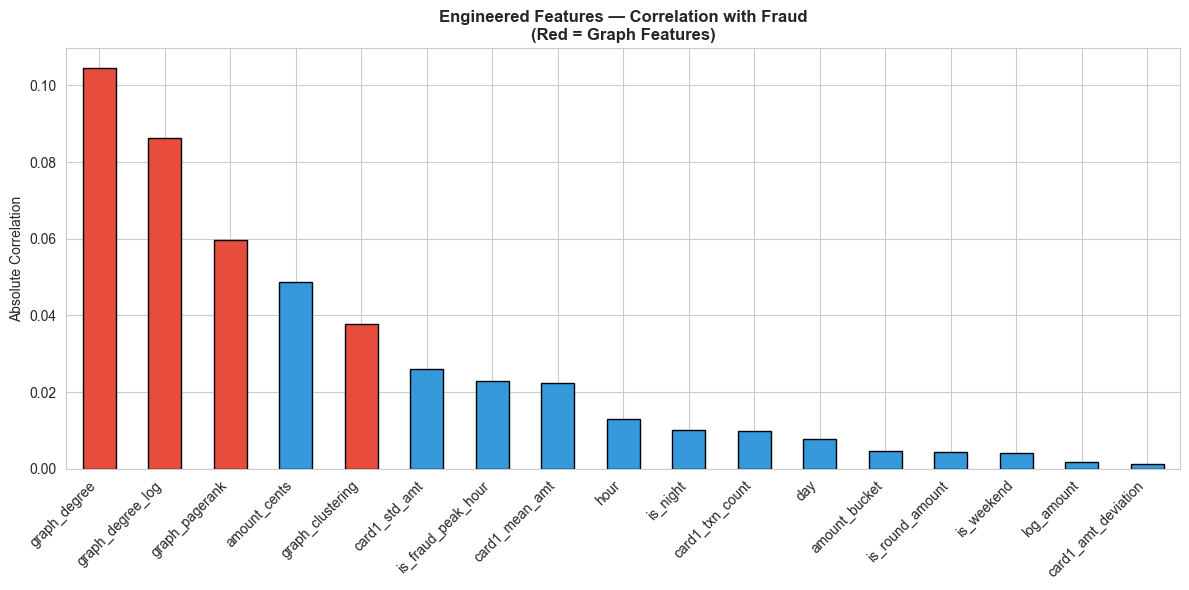

In [25]:
print("=" * 60)
print("ENGINEERED FEATURES — CORRELATION WITH FRAUD")
print("=" * 60)

# List all new features
new_features = [
    'hour', 'day', 'is_night', 'is_fraud_peak_hour', 'is_weekend',
    'log_amount', 'amount_cents', 'is_round_amount', 'amount_bucket',
    'card1_txn_count', 'card1_mean_amt', 'card1_amt_deviation', 'card1_std_amt',
    'graph_degree', 'graph_clustering', 'graph_pagerank', 'graph_degree_log',
]
new_features = [f for f in new_features if f in df.columns]

# Correlation with target
corr_new = df[new_features + ['isFraud']].corr()['isFraud'].drop('isFraud')
corr_new = corr_new.abs().sort_values(ascending=False)

print("\n📊 New Feature Correlations with Fraud:")
for feat, corr in corr_new.items():
    bar = "█" * int(corr * 200)
    tag = " 🆕 GRAPH" if 'graph' in feat else ""
    print(f"   {feat:30s} {corr:.4f} {bar}{tag}")

# Visualize
plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if 'graph' in f else '#3498db' for f in corr_new.index]
corr_new.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Engineered Features — Correlation with Fraud\n(Red = Graph Features)',
          fontweight='bold')
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("SAVING CLEAN DATASET")
print("=" * 60)

# Drop helper columns
cols_to_remove = ['time_window']
df.drop(columns=[c for c in cols_to_remove if c in df.columns], inplace=True)

# Save
df.to_csv('../data/clean_train.csv', index=False)

print(f"\n✅ Clean dataset saved to: data/clean_train.csv")
print(f"   Shape: {df.shape}")
print(f"   Size:  {df.memory_usage().sum() / 1024**2:.1f} MB (in RAM)")

# Feature count summary
print(f"""
╔═════════════════════════════════════════════════════════╗
║         PHASE 2 — FEATURE ENGINEERING COMPLETE          ║
╠═════════════════════════════════════════════════════════╣
║                                                         ║
║     FEATURES ENGINEERED                                 ║
║  → Time features    : hour, day, is_night,              ║
║                       is_fraud_peak_hour, is_weekend    ║
║  → Amount features  : log_amount, amount_cents,         ║
║                       is_round_amount, amount_bucket    ║
║  → Velocity features: txn_count, mean_amt,              ║
║                       amt_deviation, std_amt            ║
║  →    Graph features: degree, clustering,               ║
║                        pagerank, degree_log             ║
║                                                         ║
║     UNIQUE ANALYSES                                     ║
║  →    Graph-based fraud ring detection                  ║
║                                                         ║
║                                                         ║
║     DATA CLEANING                                       ║
║  → Dropped columns with >90% missing                    ║
║  → Filled remaining nulls (median / 'Unknown')          ║
║  → Label-encoded all categorical columns                ║
║  → Downcast types to save RAM                           ║
║                                                         ║
║     OUTPUT                                              ║
║  → data/clean_train.csv (model-ready!)                  ║
║                                                         ║
╠═════════════════════════════════════════════════════════╣
║     NEXT: Phase 3 — Model Training                      ║
║  → LightGBM + XGBoost ensemble                          ║
║  →    Autoencoder anomaly score                         ║
║  → SHAP explainability                                  ║
╚═════════════════════════════════════════════════════════╝
""")

SAVING CLEAN DATASET

✅ Clean dataset saved to: data/clean_train.csv
   Shape: (590540, 734)
   Size:  1224.4 MB (in RAM)

╔══════════════════════════════════════════════════════════╗
║         PHASE 2 — FEATURE ENGINEERING COMPLETE           ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  📊 FEATURES ENGINEERED                                  ║
║  → Time features    : hour, day, is_night,               ║
║                       is_fraud_peak_hour, is_weekend     ║
║  → Amount features  : log_amount, amount_cents,          ║
║                       is_round_amount, amount_bucket     ║
║  → Velocity features: txn_count, mean_amt,               ║
║                       amt_deviation, std_amt             ║
║  → 🆕 Graph features: degree, clustering,               ║
║                        pagerank, degree_log              ║
║                                                          ║
║  🔍 UNIQUE ANALYSES      